In [10]:
# Importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf

# 📊 Guía Rápida: Finanzas e Inversiones

**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**  
Facultad de Ciencias Económicas - Universidad de Buenos Aires

---

## 📚 Contenidos

1. [Conversión de Tasas](#conversiones)
2. [Valor Temporal del Dinero](#valor-temporal)
3. [VAN - Valor Actual Neto](#van)
4. [TIR y Otras Métricas](#tir)
5. [Workflow de Análisis](#workflow)
6. [Caso Práctico](#caso)
7. [Tabla de Fórmulas](#formulas)

---

<a id="conversiones"></a>

## 1️⃣ Conversión de Tasas

### 📌 Nomenclatura Estándar

| Sigla | Significado | Característica |
|-------|-------------|----------------|
| **TNA** | Tasa Nominal Anual | Sin capitalización intra-período |
| **TEA** | Tasa Efectiva Anual | Con capitalización |
| **TEM** | Tasa Efectiva Mensual | Efectiva mensual |
| **TET** | Tasa Efectiva Trimestral | Efectiva trimestral |

---

### 💡 Reconocimiento Semántico: ¿División o Equivalencia?

**División Simple (TNA):** Cuando el enunciado menciona **"costo de capital"**, **"tasa anual"** sin especificar capitalización, o en contextos de **finanzas corporativas**.

**Equivalencia (TEA):** Cuando dice explícitamente **"tasa efectiva"**, **"con capitalización"**, o en contextos **bancarios** (plazos fijos, préstamos).

**Regla práctica:**
- 💼 Finanzas corporativas/proyectos → **División** (`r/m`)
- 🏦 Productos bancarios/inversiones → **Equivalencia** (`(1+r)^(1/m) - 1`)

---

### 📐 Fórmulas de Conversión

#### **1. De TNA a TEA (con capitalización)**

$$
TEA = \left(1 + \frac{TNA}{m}\right)^m - 1
$$

Donde $m$ = capitalizaciones al año (12 mensual, 4 trimestral, 2 semestral)

#### **2. Entre tasas efectivas (equivalencia)**

$$
(1 + i_1)^{t_1} = (1 + i_2)^{t_2}
$$

**Ejemplo:** De TEA a TEM

$$
TEM = (1 + TEA)^{1/12} - 1
$$

#### **3. Proporción simple (sin capitalización)**

$$
i_{\text{período}} = TNA \times \frac{\text{días}}{360}
$$

In [11]:
# ═══════════════════════════════════════════════════════════════
# EJEMPLOS DE CONVERSIÓN DE TASAS
# ═══════════════════════════════════════════════════════════════

print("="*70)
print("CONVERSIONES DE TASAS - EJEMPLOS PRÁCTICOS")
print("="*70)

# Caso 1: TNA 36% con capitalización mensual → TEA
print("\n📌 CASO 1: TNA 36% con capitalización mensual → TEA")
print("-"*70)
TNA = 0.36
m = 12
TEA = (1 + TNA/m)**m - 1
print(f"TNA: {TNA:.2%} | Capitalización: mensual | TEA: {TEA:.4%}")

# Caso 2: TEA 15% → TEM
print("\n📌 CASO 2: TEA 15% → TEM")
print("-"*70)
TEA = 0.15
TEM = (1 + TEA)**(1/12) - 1
print(f"TEA: {TEA:.2%} | TEM: {TEM:.4%}")
print(f"Verificación: (1+TEM)^12-1 = {((1 + TEM)**12 - 1):.4%}")

# Caso 3: TNA 24% → 45 días (proporción)
print("\n📌 CASO 3: TNA 24% → Tasa para 45 días (proporción)")
print("-"*70)
TNA = 0.24
dias = 45
tasa_45d = TNA * (dias/360)
print(f"TNA: {TNA:.2%} | Período: {dias} días | Tasa: {tasa_45d:.4%}")

# Caso 4: TET 8% → TEA
print("\n📌 CASO 4: TET 8% → TEA (trimestral a anual)")
print("-"*70)
TET = 0.08
TEA_trim = (1 + TET)**4 - 1
print(f"TET: {TET:.2%} | TEA: {TEA_trim:.4%}")

# Tabla resumen
print("\n" + "="*70)
conversiones = pd.DataFrame({
    'Conversión': [
        'TNA 36% (cap. mensual) → TEA',
        'TEA 15% → TEM',
        'TNA 24% → 45 días',
        'TET 8% → TEA'
    ],
    'Resultado': [
        f'{(1 + 0.36/12)**12 - 1:.4%}',
        f'{(1 + 0.15)**(1/12) - 1:.4%}',
        f'{0.24 * 45/360:.4%}',
        f'{(1 + 0.08)**4 - 1:.4%}'
    ],
    'Método': [
        'Capitalización',
        'Equivalencia',
        'Proporción',
        'Capitalización'
    ]
})
print(conversiones.to_string(index=False))

CONVERSIONES DE TASAS - EJEMPLOS PRÁCTICOS

📌 CASO 1: TNA 36% con capitalización mensual → TEA
----------------------------------------------------------------------
TNA: 36.00% | Capitalización: mensual | TEA: 42.5761%

📌 CASO 2: TEA 15% → TEM
----------------------------------------------------------------------
TEA: 15.00% | TEM: 1.1715%
Verificación: (1+TEM)^12-1 = 15.0000%

📌 CASO 3: TNA 24% → Tasa para 45 días (proporción)
----------------------------------------------------------------------
TNA: 24.00% | Período: 45 días | Tasa: 3.0000%

📌 CASO 4: TET 8% → TEA (trimestral a anual)
----------------------------------------------------------------------
TET: 8.00% | TEA: 36.0489%

                  Conversión Resultado         Método
TNA 36% (cap. mensual) → TEA  42.5761% Capitalización
               TEA 15% → TEM   1.1715%   Equivalencia
           TNA 24% → 45 días   3.0000%     Proporción
                TET 8% → TEA  36.0489% Capitalización


<a id="valor-temporal"></a>

## 2️⃣ Valor Temporal del Dinero

### 📐 Fórmulas Básicas

| Operación | Fórmula | Uso |
|-----------|---------|-----|
| **Capitalización** | $VF = VP \times (1 + i)^n$ | Proyectar al futuro |
| **Descuento** | $VP = \frac{VF}{(1 + i)^n}$ | Traer al presente |

**Principio:** Un peso hoy vale más que un peso mañana (oportunidad + riesgo + inflación)

Valor Presente:  $100,000
Tasa:            10% anual
Períodos:        5 años
Valor Futuro:    $161,051.00

Verificación:    $100,000 (descuento)


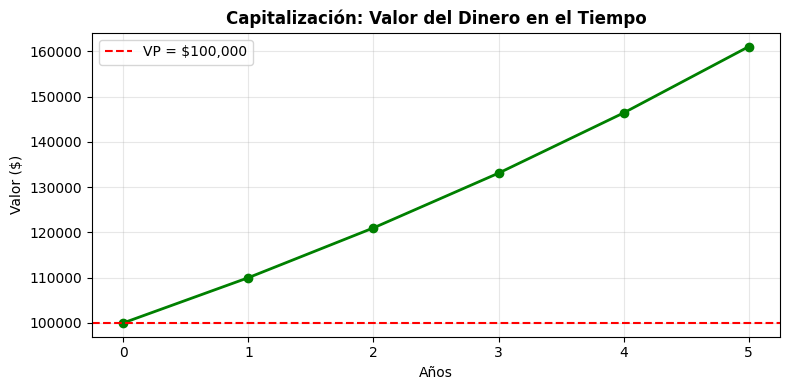

In [12]:
# Ejemplo: $100,000 al 10% anual por 5 años

vp = 100000
i = 0.10
n = 5

vf = vp * (1 + i)**n

print(f"Valor Presente:  ${vp:,.0f}")
print(f"Tasa:            {i:.0%} anual")
print(f"Períodos:        {n} años")
print(f"Valor Futuro:    ${vf:,.2f}")
print(f"\nVerificación:    ${vf / (1+i)**n:,.0f} (descuento)")

# Visualización
tiempos = np.arange(0, 6)
valores = vp * (1 + i)**tiempos

plt.figure(figsize=(8, 4))
plt.plot(tiempos, valores, marker='o', linewidth=2, color='green')
plt.axhline(vp, color='red', linestyle='--', label=f'VP = ${vp:,.0f}')
plt.title('Capitalización: Valor del Dinero en el Tiempo', fontweight='bold')
plt.xlabel('Años')
plt.ylabel('Valor ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id="van"></a>

## 3️⃣ VAN - Valor Actual Neto

### 📐 Fórmula

$$
VAN = \sum_{t=0}^{n} \frac{FC_t}{(1 + r)^t}
$$

Donde:
- $FC_t$: Flujo de caja en período $t$
- $r$: Tasa de descuento
- $FC_0$: Inversión inicial (negativa)

### 🎯 Criterio de Decisión

| VAN | Interpretación | Decisión |
|-----|----------------|----------|
| **VAN > 0** | El proyecto **crea valor** | ✅ Aceptar |
| **VAN = 0** | El proyecto rinde exactamente $r$ | ⚠️ Indiferente |
| **VAN < 0** | El proyecto **destruye valor** | ❌ Rechazar |

CÁLCULO DE VAN

Inversión Inicial: $-180,000
Tasa de descuento: 12%
Horizonte:         5 años

🎯 VAN = $64,208.97

✅ DECISIÓN: ACEPTAR
   El proyecto crea $64,208.97 de valor


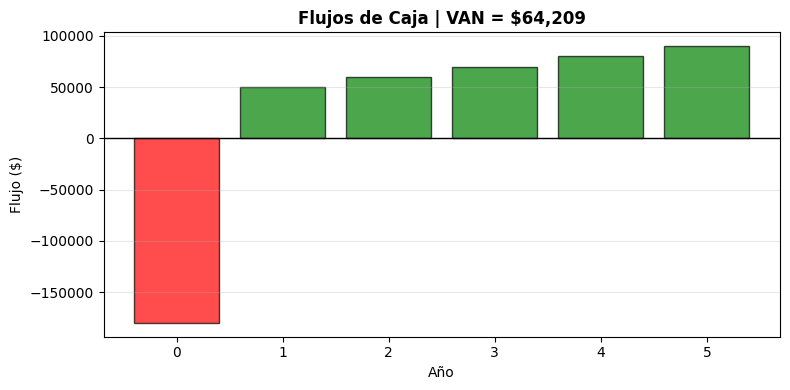

In [13]:
# Ejemplo VAN: Inversión en maquinaria

# Flujos de caja
flujos = [-180000, 50000, 60000, 70000, 80000, 90000]
años = list(range(len(flujos)))
r = 0.12  # 12% anual

# Cálculo VAN
van = npf.npv(r, flujos)

print("="*60)
print("CÁLCULO DE VAN")
print("="*60)
print(f"\nInversión Inicial: ${flujos[0]:,.0f}")
print(f"Tasa de descuento: {r:.0%}")
print(f"Horizonte:         {len(flujos)-1} años")
print(f"\n🎯 VAN = ${van:,.2f}")

if van > 0:
    print(f"\n✅ DECISIÓN: ACEPTAR")
    print(f"   El proyecto crea ${van:,.2f} de valor")
elif van < 0:
    print(f"\n❌ DECISIÓN: RECHAZAR")
    print(f"   El proyecto destruye ${abs(van):,.2f}")
else:
    print(f"\n⚠️ DECISIÓN: INDIFERENTE")

# Visualización
plt.figure(figsize=(8, 4))
colores = ['red' if f < 0 else 'green' for f in flujos]
plt.bar(años, flujos, color=colores, alpha=0.7, edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title(f'Flujos de Caja | VAN = ${van:,.0f}', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Flujo ($)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<a id="tir"></a>

## 4️⃣ TIR y Otras Métricas

### 📌 TIR - Tasa Interna de Retorno

**Definición:** Tasa de descuento que hace VAN = 0

$$
0 = \sum_{t=0}^{n} \frac{FC_t}{(1 + TIR)^t}
$$

**Criterio:** TIR > $r$ → ✅ Aceptar | TIR < $r$ → ❌ Rechazar

### 📌 Otras Métricas

| Métrica | Fórmula | Criterio |
|---------|---------|----------|
| **TIRM** | $\left(\frac{VF_{positivos}}{VP_{negativos}}\right)^{1/n} - 1$ | TIRM > $r$ |
| **IR** | $\frac{VAN}{I_0}$ | IR > 0 |
| **PRS** | Acumular $FC_t$ hasta recuperar $I_0$ | PRS < límite |
| **PRD** | Acumular $\frac{FC_t}{(1+r)^t}$ hasta 0 | PRD < límite |

In [ ]:
# Cálculo de todas las métricas

flujos = [-180000, 50000, 60000, 70000, 80000, 90000]
r = 0.12

# VAN
van = npf.npv(r, flujos)

# TIR
tir = npf.irr(flujos)

# TIRM
tirm = npf.mirr(flujos, r, r)

# IR (Índice de Rentabilidad)
ir = van / abs(flujos[0])

# PRS (Período Recuperación Simple)
inversion_inicial = abs(flujos[0])
acum = 0
prs = None
for t in range(len(flujos)):
    acum += flujos[t]
    if acum >= 0 and prs is None:
        acum_anterior = acum - flujos[t]
        remaining_needed = abs(acum_anterior)
        if flujos[t] > 0:
            prs = t - 1 + (remaining_needed / flujos[t])
        break

# PRD (Período Recuperación Descontado)
acum_desc = 0
prd = None
for t in range(len(flujos)):
    if t == 0:
        fc_desc = flujos[t]
    else:
        fc_desc = flujos[t] / (1 + r)**t
    acum_desc += fc_desc
    
    if acum_desc >= 0 and prd is None:
        acum_desc_anterior = acum_desc - fc_desc
        remaining_needed_desc = abs(acum_desc_anterior)
        if fc_desc > 0:
            prd = t - 1 + (remaining_needed_desc / fc_desc)
        break

# Resultados
print("="*60)
print("RESUMEN DE MÉTRICAS")
print("="*60)

print(f"\n📊 VAN:   ${van:,.2f}")
print(f"   {'✅ Positivo - Crea valor' if van > 0 else '❌ Negativo - Destruye valor'}")

print(f"\n📈 TIR:   {tir:.2%}")
print(f"   {'✅ Mayor que r ('+str(round(r*100))+'%)' if tir > r else '❌ Menor que r'}")

print(f"\n📊 TIRM:  {tirm:.2%}")
print(f"   {'✅ Mayor que r' if tirm > r else '❌ Menor que r'}")

print(f"\n💰 IR:    {ir:.2f}")
print(f"   Por cada $1 invertido, se crean ${ir:.2f}")

print(f"\n⏱️  PRS:   {prs:.2f} años")
print(f"   Recuperación simple de la inversión")

print(f"\n⏱️  PRD:   {prd:.2f} años")
print(f"   Recuperación descontada (considera valor del dinero)")


print("\n" + "="*60)    print("\n❌ PROYECTO NO VIABLE - SE RECOMIENDA RECHAZAR")

print("DECISIÓN FINAL")else:

print("="*60)    print(f"   • TIR ({tir:.1%}) supera la tasa de descuento ({r:.0%})")

    print("   • VAN positivo: crea valor")

if van > 0 and tir > r:    print("\n✅ PROYECTO VIABLE - SE RECOMIENDA ACEPTAR")

RESUMEN DE MÉTRICAS

📊 VAN:   $64,208.97
   ✅ Positivo - Crea valor

📈 TIR:   24.14%
   ✅ Mayor que r (12%)

📊 TIRM:  19.05%
   ✅ Mayor que r

💰 IR:    0.36
   Por cada $1 invertido, se crean $0.36

⏱️  PRS:   3.00 años
   Recuperación simple de la inversión

⏱️  PRD:   3.74 años
   Recuperación descontada (considera valor del dinero)

DECISIÓN FINAL

✅ PROYECTO VIABLE - SE RECOMIENDA ACEPTAR
   • VAN positivo: crea valor
   • TIR (24.1%) supera la tasa de descuento (12%)


<a id="workflow"></a>

## 5️⃣ Workflow de Análisis

### 🔄 Proceso Sistemático

```
1. RECOPILAR DATOS
   ├─ Inversión inicial (t=0)
   ├─ Flujos operativos (t=1,2,...,n)
   └─ Valor residual (si aplica)

2. DETERMINAR TASA DE DESCUENTO
   ├─ CAPM: r = rf + β(rm - rf)
   └─ WACC: para proyectos con financiamiento

3. CALCULAR MÉTRICAS
   ├─ VAN
   ├─ TIR
   ├─ TIRM
   ├─ IR
   ├─ PRS
   └─ PRD

4. INTERPRETAR
   ├─ ¿VAN > 0?
   ├─ ¿TIR > r?
   └─ ¿Consistencia entre métricas?

5. ANÁLISIS DE SENSIBILIDAD
   ├─ Escenario pesimista
   ├─ Escenario optimista
   └─ Variación de tasa

6. DECISIÓN FINAL
   └─ Aceptar / Rechazar / Revisar
```

In [ ]:
# Template reutilizable para evaluación

def evaluar_proyecto(flujos, tasa, nombre="Proyecto"):
    """
    Evalúa un proyecto calculando todas las métricas.
    
    Args:
        flujos (list): [F0, F1, ..., Fn] donde F0 < 0
        tasa (float): Tasa de descuento anual (decimal)
        nombre (str): Nombre del proyecto
    """
    
    print("="*60)
    print(f"EVALUACIÓN: {nombre.upper()}")
    print("="*60)
    
    # Cálculos
    van = npf.npv(tasa, flujos)
    tir = npf.irr(flujos)
    tirm = npf.mirr(flujos, tasa, tasa)
    ir = van / abs(flujos[0]) if flujos[0] != 0 else 0
    
    # PRS (Período Recuperación Simple)
    inversion_inicial = abs(flujos[0])
    acum = 0
    prs = None
    for t in range(len(flujos)):
        acum += flujos[t]
        if acum >= 0 and prs is None:
            acum_anterior = acum - flujos[t]
            remaining_needed = abs(acum_anterior)
            if flujos[t] > 0:
                prs = t - 1 + (remaining_needed / flujos[t])
            break
    
    # PRD (Período Recuperación Descontado)
    acum_desc = 0
    prd = None
    for t in range(len(flujos)):
        if t == 0:
            fc_desc = flujos[t]
        else:
            fc_desc = flujos[t] / (1 + tasa)**t
        acum_desc += fc_desc
        
        if acum_desc >= 0 and prd is None:
            acum_desc_anterior = acum_desc - fc_desc
            remaining_needed_desc = abs(acum_desc_anterior)
            if fc_desc > 0:
                prd = t - 1 + (remaining_needed_desc / fc_desc)
            break
    
    # Resultados
    print(f"\nInversión:  ${abs(flujos[0]):,.0f}")
    print(f"Tasa:       {tasa:.1%}")
    print(f"Horizonte:  {len(flujos)-1} períodos\n")
    
    print(f"VAN:   ${van:,.0f}  {'✅' if van > 0 else '❌'}")
    print(f"TIR:   {tir:.2%}     {'✅' if tir > tasa else '❌'}")
    print(f"TIRM:  {tirm:.2%}     {'✅' if tirm > tasa else '❌'}")
    print(f"IR:    {ir:.2f}      {'✅' if ir > 0 else '❌'}")
    print(f"PRS:   {prs:.2f} años" if prs else "PRS:   No se recupera")
    print(f"PRD:   {prd:.2f} años" if prd else "PRD:   No se recupera")
    
    print("\n" + "="*60)
    if van > 0 and tir > tasa:

        print("DECISIÓN: ✅ ACEPTAR PROYECTO")evaluar_proyecto(flujos_ejemplo, 0.12, "Maquinaria Nueva")

    else:flujos_ejemplo = [-180000, 50000, 60000, 70000, 80000, 90000]

        print("DECISIÓN: ❌ RECHAZAR PROYECTO")# Ejemplo de uso

    print("="*60)

        return {'VAN': van, 'TIR': tir, 'TIRM': tirm, 'IR': ir, 'PRS': prs, 'PRD': prd}

EVALUACIÓN: MAQUINARIA NUEVA

Inversión:  $180,000
Tasa:       12.0%
Horizonte:  5 períodos

VAN:   $64,209  ✅
TIR:   24.14%     ✅
TIRM:  19.05%     ✅
IR:    0.36      ✅
PRS:   3.00 años
PRD:   3.74 años

DECISIÓN: ✅ ACEPTAR PROYECTO


{'VAN': np.float64(64208.97042991752),
 'TIR': 0.24143254299361705,
 'TIRM': np.float64(0.19046284171057648),
 'IR': np.float64(0.35671650238843067),
 'PRS': 3.0,
 'PRD': 3.741538560000001}

<a id="caso"></a>

## 6️⃣ Caso Práctico: Inversión en YPF

### 🎯 Contexto

Evaluar la compra de 1,000 acciones de YPF para mantener 5 años.

**Datos:**
- Precio inicial: $450/acción
- Precios proyectados: [520, 580, 650, 720, 800]
- Tasa libre de riesgo: 4%
- Beta YPF: 1.45
- Rendimiento mercado: 8.5%

CASO: INVERSIÓN EN ACCIONES YPF

📊 TASA CAPM: 10.5250%
   r = 4.0% + 1.45×(8.5% - 4.0%) = 10.53%

💰 FLUJOS DE CAJA:
   Año 0: $-450,000
   Año 1: $70,000
   Año 2: $60,000
   Año 3: $70,000
   Año 4: $70,000
   Año 5: $800,000


EVALUACIÓN: INVERSIÓN YPF

Inversión:  $450,000
Tasa:       10.5%
Horizonte:  5 períodos

VAN:   $246,257  ✅
TIR:   22.93%     ✅
TIRM:  20.61%     ✅
IR:    0.55      ✅
PRS:   4.22 años
PRD:   4.49 años

DECISIÓN: ✅ ACEPTAR PROYECTO


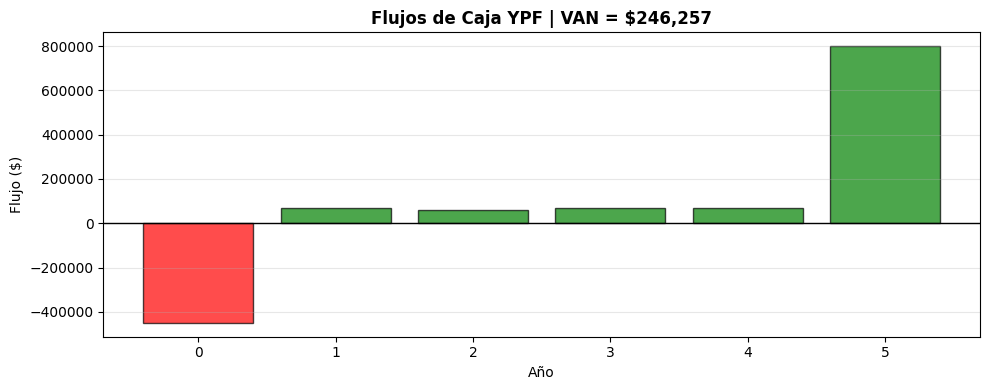

In [16]:
# CASO: Inversión en acciones YPF

# Datos
precio_inicial = 450
precios = [520, 580, 650, 720, 800]
cantidad = 1000

# Tasa de descuento CAPM
rf = 0.04
beta = 1.45
rm = 0.085
r_capm = rf + beta * (rm - rf)

print("="*60)
print("CASO: INVERSIÓN EN ACCIONES YPF")
print("="*60)

print(f"\n📊 TASA CAPM: {r_capm:.4%}")
print(f"   r = {rf:.1%} + {beta}×({rm:.1%} - {rf:.1%}) = {r_capm:.2%}")

# Construir flujos de caja
inversion = -precio_inicial * cantidad
flujos = [inversion]

# Flujos intermedios (cambios de valor)
precio_anterior = precio_inicial
for precio in precios[:-1]:
    flujo = (precio - precio_anterior) * cantidad
    flujos.append(flujo)
    precio_anterior = precio

# Flujo final (venta)
flujo_final = precios[-1] * cantidad
flujos.append(flujo_final)

print(f"\n💰 FLUJOS DE CAJA:")
for t, flujo in enumerate(flujos):
    print(f"   Año {t}: ${flujo:,.0f}")

# Evaluar
print("\n")
resultados = evaluar_proyecto(flujos, r_capm, "Inversión YPF")

# Visualización
años = list(range(len(flujos)))
colores = ['red' if f < 0 else 'green' for f in flujos]

plt.figure(figsize=(10, 4))
plt.bar(años, flujos, color=colores, alpha=0.7, edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title(f'Flujos de Caja YPF | VAN = ${resultados["VAN"]:,.0f}', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Flujo ($)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<a id="formulas"></a>

## 7️⃣ Tabla de Fórmulas - Referencia Rápida

### 🔹 Tasas

| Fórmula | Descripción |
|---------|-------------|
| $TEA = \left(1 + \frac{TNA}{m}\right)^m - 1$ | TNA → TEA con $m$ capitalizaciones |
| $i_2 = (1 + i_1)^{t_2/t_1} - 1$ | Equivalencia entre tasas efectivas |
| $i = TNA \times \frac{días}{360}$ | Proporción simple |

### 🔹 Reconocimiento de Tasas en Enunciados

| Contexto | Método | Palabras Clave |
|----------|--------|----------------|
| **Finanzas corporativas** | División simple | "costo de capital", "tasa anual" |
| **Productos bancarios** | Equivalencia | "tasa efectiva", "TEA", "con capitalización" |
| **Proyectos de inversión** | División simple | "VAN", "TIR", "flujos descontados" |
| **Préstamos/Plazos fijos** | Equivalencia | "banco", "rendimiento", "interés compuesto" |

**Regla práctica:** Si el enunciado NO dice explícitamente "efectiva" → usar **división simple**.

### 🔹 Valor Temporal

| Fórmula | Descripción |
|---------|-------------|
| $VF = VP \times (1 + i)^n$ | Capitalización |
| $VP = \frac{VF}{(1 + i)^n}$ | Descuento |

### 🔹 Evaluación de Proyectos

| Métrica | Fórmula | Criterio |
|---------|---------|----------|
| **VAN** | $\sum_{t=0}^{n} \frac{FC_t}{(1 + r)^t}$ | VAN > 0 |
| **TIR** | $0 = \sum_{t=0}^{n} \frac{FC_t}{(1 + TIR)^t}$ | TIR > $r$ |
| **IR** | $\frac{VAN}{I_0}$ | IR > 0 |
| **CAPM** | $r = r_f + \beta(r_m - r_f)$ | Tasa de descuento |

### 🔹 Funciones NumPy Financial

```python
import numpy_financial as npf

van = npf.npv(tasa, flujos)        # VAN
tir = npf.irr(flujos)              # TIR
tirm = npf.mirr(flujos, r, r)     # TIRM
```

---

## ✅ Checklist de Verificación

- [ ] Definir inversión inicial (negativa)
- [ ] Proyectar flujos operativos
- [ ] Calcular tasa de descuento (CAPM/WACC)
- [ ] **Identificar tipo de tasa** (nominal vs efectiva)
- [ ] Computar VAN
- [ ] Computar TIR
- [ ] Verificar consistencia (VAN y TIR apuntan igual)
- [ ] Análisis de sensibilidad
- [ ] Decisión fundamentada

---

**🎓 Laboratorio TGAD - FCE UBA**

Esta guía rápida consolida los conceptos esenciales sin redundancias. Para profundizar, consultar la guía completa o bibliografía recomendada.